In [16]:
# Define the path to the configuration file for the embedding pipeline
config_file_path = "data/configs/embeddings/25_test_documents_en_embedding_config.yaml"

In [17]:
# Runs the embedding pipeline with the specified configuration file
run_embedding_pipeline(Path(config_file_path))

2025-11-18 11:30:59.156 | INFO     | datatrove.executor.local:run:107 - Not doing anything as all 1 tasks have already been completed.


Running Local Pipeline Executor


In [19]:
# Load embeddings
import h5py
import yaml
from pathlib import Path
import numpy as np

with open(config_file_path, "r") as f:
        config = yaml.safe_load(f)

output_dir = config["params"]["output_dir"]
embedding_dir = Path(output_dir) / config["params"]["embedding_dir"]

hdf5_files = sorted(list(embedding_dir.glob("*.h5")))

embeddings = []

for file_path in hdf5_files:
    with h5py.File(file_path, "r") as f:
        # get dataset name
        key = list(f.keys())[0]      
        embedding = f[key]["embeddings"][:]
        embeddings.append(embedding)
            

# Concatenate all embeddings into one numpy array (optional)
all_embeddings = np.vstack(embeddings)

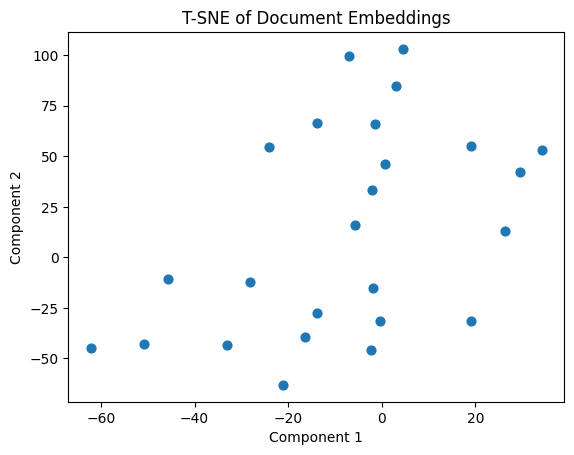

In [21]:
# Plot embeddings
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(
    n_components=2,
    perplexity=5,         
    learning_rate="auto",
    init="random",
    random_state=42,
)

emb_2d = tsne.fit_transform(all_embeddings)

plt.scatter(emb_2d[:, 0], emb_2d[:, 1], s=40)
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.title("T-SNE of Document Embeddings")
plt.show()